In [34]:
import pandas as pd

data = {
    "mode": [
        "private_car", "car_sharing", "private_bike", "bike_sharing",
        "e_scooter_sharing", "e_scooter_private", "taxi",
        "ride_hailing", "public_transport"
    ],
    "distance_km": [2.5,2.5,2.5,2.5,2.5,2.5,2.5,2.5,2.5],
    "travel_time_min": [7,7,12,12,9.5, 9.5,7,7,15],
    "access_time_min": [0,5,0,5,5,0,0,2,6],
    "waiting_time_min": [0,0,0,0,0,0,4,5,7.5],
    "transfers": [0,0,0,0,0,0,0,0,0]
}

df = pd.DataFrame(data)
df

,mode,distance_km,travel_time_min,access_time_min,waiting_time_min,transfers
0,private_car,2.5,7.0,0,0.0,0
1,car_sharing,2.5,7.0,5,0.0,0
2,private_bike,2.5,12.0,0,0.0,0
3,bike_sharing,2.5,12.0,5,0.0,0
4,e_scooter_sharing,2.5,9.5,5,0.0,0
5,e_scooter_private,2.5,9.5,0,0.0,0
6,taxi,2.5,7.0,0,4.0,0
7,ride_hailing,2.5,7.0,2,5.0,0
8,public_transport,2.5,15.0,6,7.5,0


In [35]:
df["total_time_min"] = (
    df["travel_time_min"] +
    df["access_time_min"] +
    df["waiting_time_min"]
)
df

,mode,distance_km,travel_time_min,access_time_min,waiting_time_min,transfers,total_time_min
0,private_car,2.5,7.0,0,0.0,0,7.0
1,car_sharing,2.5,7.0,5,0.0,0,12.0
2,private_bike,2.5,12.0,0,0.0,0,12.0
3,bike_sharing,2.5,12.0,5,0.0,0,17.0
4,e_scooter_sharing,2.5,9.5,5,0.0,0,14.5
5,e_scooter_private,2.5,9.5,0,0.0,0,9.5
6,taxi,2.5,7.0,0,4.0,0,11.0
7,ride_hailing,2.5,7.0,2,5.0,0,14.0
8,public_transport,2.5,15.0,6,7.5,0,28.5


In [36]:
df.to_csv("trip_base_data.csv", index=False)

In [37]:
cost_data = {
    "mode": ["private_car", "car_sharing", "private_bike", "bike_sharing",
        "e_scooter_sharing", "e_scooter_private", "taxi",
        "ride_hailing", "public_transport"],
    "cost_euro": [1.5,3,0, 2.35, 1.7,0.3,9,7,0.8]
}

df_cost = pd.DataFrame(cost_data)
df_cost

,mode,cost_euro
0,private_car,1.50
1,car_sharing,3.00
2,private_bike,0.00
3,bike_sharing,2.35
4,e_scooter_sharing,1.70
5,e_scooter_private,0.30
6,taxi,9.00
7,ride_hailing,7.00
8,public_transport,0.80


In [38]:
df_final = df.merge(df_cost, on="mode")
df_final

,mode,distance_km,travel_time_min,access_time_min,waiting_time_min,transfers,total_time_min,cost_euro
0,private_car,2.5,7.0,0,0.0,0,7.0,1.50
1,car_sharing,2.5,7.0,5,0.0,0,12.0,3.00
2,private_bike,2.5,12.0,0,0.0,0,12.0,0.00
3,bike_sharing,2.5,12.0,5,0.0,0,17.0,2.35
4,e_scooter_sharing,2.5,9.5,5,0.0,0,14.5,1.70
5,e_scooter_private,2.5,9.5,0,0.0,0,9.5,0.30
6,taxi,2.5,7.0,0,4.0,0,11.0,9.00
7,ride_hailing,2.5,7.0,2,5.0,0,14.0,7.00
8,public_transport,2.5,15.0,6,7.5,0,28.5,0.80


In [39]:
vot_per_min = 10 / 60

In [40]:
df_final["time_cost_euro"] = df_final["total_time_min"] * vot_per_min

In [41]:
df_final["generalised_cost"] = (
    df_final["cost_euro"] + df_final["time_cost_euro"]
)

In [42]:
df_final = df_final.sort_values("generalised_cost")
df_final

,mode,distance_km,travel_time_min,access_time_min,waiting_time_min,transfers,total_time_min,cost_euro,time_cost_euro,generalised_cost
5,e_scooter_private,2.5,9.5,0,0.0,0,9.5,0.30,1.583333,1.883333
2,private_bike,2.5,12.0,0,0.0,0,12.0,0.00,2.000000,2.000000
0,private_car,2.5,7.0,0,0.0,0,7.0,1.50,1.166667,2.666667
4,e_scooter_sharing,2.5,9.5,5,0.0,0,14.5,1.70,2.416667,4.116667
1,car_sharing,2.5,7.0,5,0.0,0,12.0,3.00,2.000000,5.000000
3,bike_sharing,2.5,12.0,5,0.0,0,17.0,2.35,2.833333,5.183333
8,public_transport,2.5,15.0,6,7.5,0,28.5,0.80,4.750000,5.550000
7,ride_hailing,2.5,7.0,2,5.0,0,14.0,7.00,2.333333,9.333333
6,taxi,2.5,7.0,0,4.0,0,11.0,9.00,1.833333,10.833333


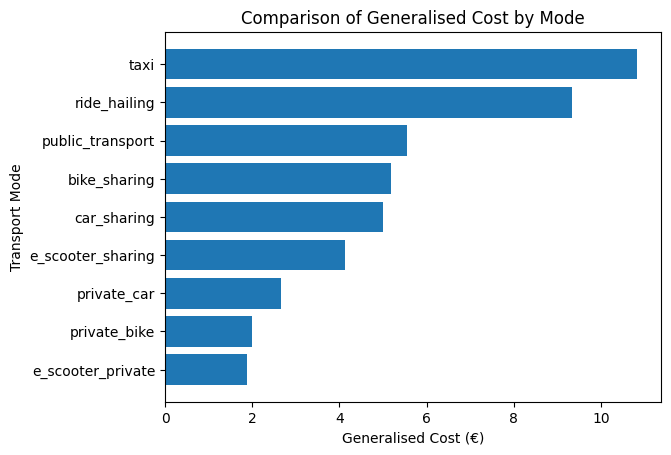

In [43]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(df_final["mode"], df_final["generalised_cost"])
plt.xlabel("Generalised Cost (€)")
plt.ylabel("Transport Mode")
plt.title("Comparison of Generalised Cost by Mode")
plt.show()

In [44]:
P = 15000        # price (€)
VR = 3000        # residual value (€)
n = 10           # years
i = 0.05         # interest rate
annual_km = 10000

In [45]:
depreciation = (P - VR) * (((1+i)**n * i) / (((1+i)**n) - 1)) + (VR * i)
depreciation

1704.0548995854795

In [46]:
insurance = 600
tax = 200
revision = 100
parking = 300

In [47]:
fixed_cost = insurance + tax + revision + parking + A
fixed_cost

2904.0548995854797

In [48]:
fuel = 1200
maintenance = 400
tyres = 200
oil = 100

In [49]:
variable_cost = fuel + maintenance + tyres + oil
variable_cost

1900

In [50]:
variable_cost = fuel + maintenance + tyres + oil
variable_cost

1900

In [51]:
total_annual_cost = fixed_cost + variable_cost
total_annual_cost

4804.05489958548

In [52]:
cost_per_km = total_annual_cost / annual_km
cost_per_km

0.480405489958548

In [53]:
trip_cost = cost_per_km * 2.5
trip_cost

1.20101372489637

In [54]:
df_final.loc[df_final["mode"] == "private_car", "cost_euro"] = 1.20

In [55]:
vot_per_min = 10 / 60

df_final["time_cost_euro"] = df_final["total_time_min"] * vot_per_min

df_final["generalised_cost"] = (
    df_final["cost_euro"] + df_final["time_cost_euro"]
)

df_final = df_final.sort_values("generalised_cost")
df_final

,mode,distance_km,travel_time_min,access_time_min,waiting_time_min,transfers,total_time_min,cost_euro,time_cost_euro,generalised_cost
5,e_scooter_private,2.5,9.5,0,0.0,0,9.5,0.30,1.583333,1.883333
2,private_bike,2.5,12.0,0,0.0,0,12.0,0.00,2.000000,2.000000
0,private_car,2.5,7.0,0,0.0,0,7.0,1.20,1.166667,2.366667
4,e_scooter_sharing,2.5,9.5,5,0.0,0,14.5,1.70,2.416667,4.116667
1,car_sharing,2.5,7.0,5,0.0,0,12.0,3.00,2.000000,5.000000
3,bike_sharing,2.5,12.0,5,0.0,0,17.0,2.35,2.833333,5.183333
8,public_transport,2.5,15.0,6,7.5,0,28.5,0.80,4.750000,5.550000
7,ride_hailing,2.5,7.0,2,5.0,0,14.0,7.00,2.333333,9.333333
6,taxi,2.5,7.0,0,4.0,0,11.0,9.00,1.833333,10.833333


In [58]:
vot_values = [5, 10, 20]

In [56]:
df_sens = df_final[["mode", "cost_euro", "total_time_min"]].copy()

In [59]:
for vot in vot_values:
    vot_per_min = vot / 60
    df_sens[f"GC_vot_{vot}"] = (
        df_sens["cost_euro"] +
        df_sens["total_time_min"] * vot_per_min
    )

df_sens

,mode,cost_euro,total_time_min,GC_vot_5,GC_vot_10,GC_vot_20
5,e_scooter_private,0.30,9.5,1.091667,1.883333,3.466667
2,private_bike,0.00,12.0,1.000000,2.000000,4.000000
0,private_car,1.20,7.0,1.783333,2.366667,3.533333
4,e_scooter_sharing,1.70,14.5,2.908333,4.116667,6.533333
1,car_sharing,3.00,12.0,4.000000,5.000000,7.000000
3,bike_sharing,2.35,17.0,3.766667,5.183333,8.016667
8,public_transport,0.80,28.5,3.175000,5.550000,10.300000
7,ride_hailing,7.00,14.0,8.166667,9.333333,11.666667
6,taxi,9.00,11.0,9.916667,10.833333,12.666667


In [60]:
df_sens = df_sens.sort_values("GC_vot_10")
df_sens

,mode,cost_euro,total_time_min,GC_vot_5,GC_vot_10,GC_vot_20
5,e_scooter_private,0.30,9.5,1.091667,1.883333,3.466667
2,private_bike,0.00,12.0,1.000000,2.000000,4.000000
0,private_car,1.20,7.0,1.783333,2.366667,3.533333
4,e_scooter_sharing,1.70,14.5,2.908333,4.116667,6.533333
1,car_sharing,3.00,12.0,4.000000,5.000000,7.000000
3,bike_sharing,2.35,17.0,3.766667,5.183333,8.016667
8,public_transport,0.80,28.5,3.175000,5.550000,10.300000
7,ride_hailing,7.00,14.0,8.166667,9.333333,11.666667
6,taxi,9.00,11.0,9.916667,10.833333,12.666667


In [61]:
vot_per_min = 10 / 60

df_final["travel_cost"] = df_final["travel_time_min"] * vot_per_min
df_final["access_cost"] = df_final["access_time_min"] * vot_per_min
df_final["waiting_cost"] = df_final["waiting_time_min"] * vot_per_min

In [62]:
df_final[[
    "mode",
    "travel_cost",
    "access_cost",
    "waiting_cost",
    "time_cost_euro"
]]

,mode,travel_cost,access_cost,waiting_cost,time_cost_euro
5,e_scooter_private,1.583333,0.000000,0.000000,1.583333
2,private_bike,2.000000,0.000000,0.000000,2.000000
0,private_car,1.166667,0.000000,0.000000,1.166667
4,e_scooter_sharing,1.583333,0.833333,0.000000,2.416667
1,car_sharing,1.166667,0.833333,0.000000,2.000000
3,bike_sharing,2.000000,0.833333,0.000000,2.833333
8,public_transport,2.500000,1.000000,1.250000,4.750000
7,ride_hailing,1.166667,0.333333,0.833333,2.333333
6,taxi,1.166667,0.000000,0.666667,1.833333


In [65]:
import plotly.graph_objects as go

df_plot = df_final.sort_values("generalised_cost")

fig = go.Figure()

fig.add_trace(go.Bar(
    y=df_plot["mode"],
    x=df_plot["travel_cost"],
    name="Travel Time",
    orientation='h'
))

fig.add_trace(go.Bar(
    y=df_plot["mode"],
    x=df_plot["access_cost"],
    name="Access Time",
    orientation='h'
))

fig.add_trace(go.Bar(
    y=df_plot["mode"],
    x=df_plot["waiting_cost"],
    name="Waiting Time",
    orientation='h'
))

fig.update_layout(
    barmode='stack',
    title="Decomposition of Time Cost by Component",
    xaxis_title="Time Cost (€)",
    yaxis_title="Transport Mode",
    template="plotly_white"
)

fig.show()

In [67]:
w_travel = 1
w_access = 1.5
w_waiting = 2

In [70]:
df_final["weighted_time_min"] = (
    df_final["travel_time_min"] * w_travel +
    df_final["access_time_min"] * w_access +
    df_final["waiting_time_min"] * w_waiting
)

In [71]:
vot_per_min = 10 / 60

df_final["weighted_time_cost"] = (
    df_final["weighted_time_min"] * vot_per_min
)

In [72]:
df_final["GC_weighted"] = (
    df_final["cost_euro"] + df_final["weighted_time_cost"]
)

In [73]:
df_weighted = df_final.sort_values("GC_weighted")
df_weighted[["mode", "GC_weighted"]]

,mode,GC_weighted
5,e_scooter_private,1.883333
2,private_bike,2.000000
0,private_car,2.366667
4,e_scooter_sharing,4.533333
1,car_sharing,5.416667
3,bike_sharing,5.600000
8,public_transport,7.300000
7,ride_hailing,10.333333
6,taxi,11.500000


In [79]:
import plotly.graph_objects as go

df_plot = df_final.sort_values("generalised_cost")

fig = go.Figure()

for i, row in df_plot.iterrows():
    fig.add_trace(go.Scatter(
        x=[row["generalised_cost"], row["GC_weighted"]],
        y=[row["mode"], row["mode"]],
        mode='lines+markers',
        line=dict(color='gray', width=2),
        marker=dict(size=8),
        showlegend=False
    ))

fig.update_layout(
    title="Impact of Time Weighting on Generalised Cost",
    xaxis_title="Cost (€)",
    yaxis_title="Transport Mode",
    template="plotly_white"
)

fig.show()

In [75]:
color = "red" if row["GC_weighted"] > row["generalised_cost"] else "blue"

In [80]:
import plotly.express as px

fig = px.scatter(
    df_final,
    x="cost_euro",
    y="total_time_min",
    text="mode",
    title="Pareto Analysis: Cost vs Travel Time",
    labels={
        "cost_euro": "Cost (€)",
        "total_time_min": "Total Time (min)"
    }
)

fig.update_traces(textposition='top center')

fig.update_layout(template="plotly_white")

fig.show()

In [81]:
df_pareto = df_final.sort_values(["cost_euro", "total_time_min"])

df_pareto

,mode,distance_km,travel_time_min,access_time_min,waiting_time_min,transfers,total_time_min,cost_euro,time_cost_euro,generalised_cost,travel_cost,access_cost,waiting_cost,weighted_time,weighted_time_cost,GC_weighted,weighted_time_min
2,private_bike,2.5,12.0,0,0.0,0,12.0,0.00,2.000000,2.000000,2.000000,0.000000,0.000000,12.0,2.000000,2.000000,12.0
5,e_scooter_private,2.5,9.5,0,0.0,0,9.5,0.30,1.583333,1.883333,1.583333,0.000000,0.000000,9.5,1.583333,1.883333,9.5
8,public_transport,2.5,15.0,6,7.5,0,28.5,0.80,4.750000,5.550000,2.500000,1.000000,1.250000,39.0,6.500000,7.300000,39.0
0,private_car,2.5,7.0,0,0.0,0,7.0,1.20,1.166667,2.366667,1.166667,0.000000,0.000000,7.0,1.166667,2.366667,7.0
4,e_scooter_sharing,2.5,9.5,5,0.0,0,14.5,1.70,2.416667,4.116667,1.583333,0.833333,0.000000,17.0,2.833333,4.533333,17.0
3,bike_sharing,2.5,12.0,5,0.0,0,17.0,2.35,2.833333,5.183333,2.000000,0.833333,0.000000,19.5,3.250000,5.600000,19.5
1,car_sharing,2.5,7.0,5,0.0,0,12.0,3.00,2.000000,5.000000,1.166667,0.833333,0.000000,14.5,2.416667,5.416667,14.5
7,ride_hailing,2.5,7.0,2,5.0,0,14.0,7.00,2.333333,9.333333,1.166667,0.333333,0.833333,20.0,3.333333,10.333333,20.0
6,taxi,2.5,7.0,0,4.0,0,11.0,9.00,1.833333,10.833333,1.166667,0.000000,0.666667,15.0,2.500000,11.500000,15.0


In [82]:
# cost-focused (زمان مهم نیست)
vot_low = 1 / 60

df_final["GC_lowVOT"] = (
    df_final["cost_euro"] +
    df_final["total_time_min"] * vot_low
)

# time-focused (زمان خیلی مهم)
vot_high = 20 / 60

df_final["GC_highVOT"] = (
    df_final["cost_euro"] +
    df_final["total_time_min"] * vot_high
)

In [83]:
df_low = df_final.sort_values("GC_lowVOT")
df_high = df_final.sort_values("GC_highVOT")

In [84]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Bar(
    y=df_low["mode"],
    x=df_low["GC_lowVOT"],
    name="Cost-focused (Low VOT)",
    orientation='h'
))

fig.add_trace(go.Bar(
    y=df_high["mode"],
    x=df_high["GC_highVOT"],
    name="Time-focused (High VOT)",
    orientation='h'
))

fig.update_layout(
    barmode='group',
    title="Mode Ranking under Different User Preferences",
    xaxis_title="Generalised Cost (€)",
    yaxis_title="Transport Mode",
    template="plotly_white"
)

fig.show()